In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import make_blobs 
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler

In [5]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [7]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [8]:
df.head()

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [21]:
inertia = []
K_range = range(1, 11)

In [22]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [23]:
inertia

[1000.0000000000002,
 297.89541410517234,
 11.575484723104983,
 9.752067977356848,
 8.257175272446283,
 6.917577320416797,
 6.334755391595287,
 5.704177177901432,
 5.060234133532079,
 4.7623618981304]

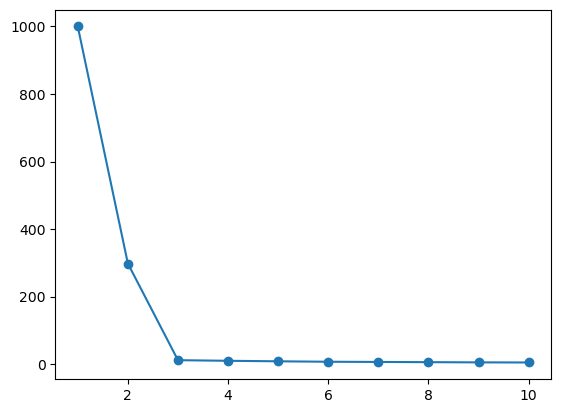

In [30]:
plt.plot(K_range, inertia, marker='o')

In [31]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [32]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [37]:
df['cluster'] = cluster_labels

In [38]:
print(df.columns)

Index(['Feature_1', 'Feature_2', 'cluster'], dtype='object')


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

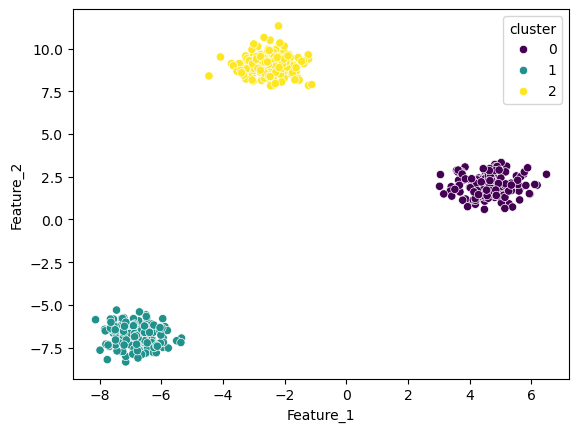

In [39]:
sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['cluster'],
    palette='viridis'
)

In [40]:
from sklearn.datasets import make_moons

In [42]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [43]:
from sklearn.cluster import KMeans, DBSCAN

In [44]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [45]:
scaler = StandardScaler()

In [46]:
X_scaled = scaler.fit_transform(df)

In [47]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [48]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

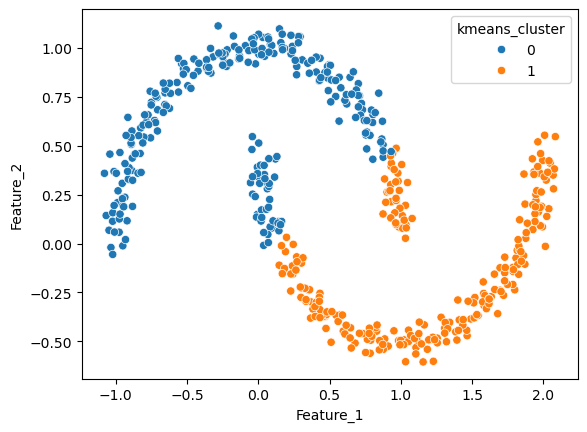

In [49]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')

In [51]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [52]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

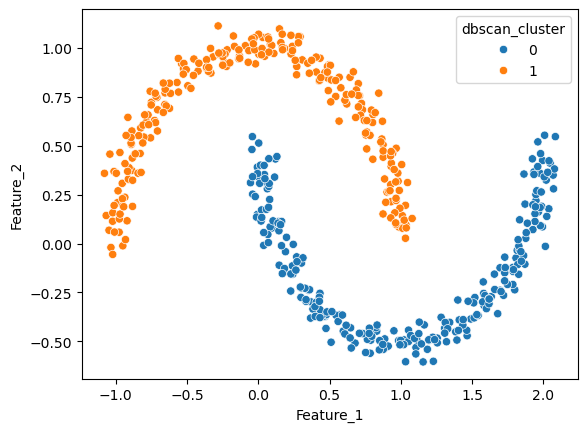

In [54]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')

In [55]:
from sklearn.decomposition import PCA 

In [65]:
X, y = make_blobs(n_samples=500,n_features=5, cluster_std=0.60, random_state=42)

In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [67]:
 X_scaled

array([[-1.12937471,  0.73936542,  0.25536042, -1.51767371, -0.76613646],
       [-0.88716838,  0.68665398,  0.2561749 , -1.24936973, -0.67556887],
       [ 1.11061452,  0.58218963, -1.33128703,  0.5031012 , -0.76745287],
       ...,
       [-0.04659077, -1.34057871,  0.89705734,  0.77390015,  1.65803151],
       [ 1.27794593,  0.71956664, -0.72898513,  0.58367122, -0.80212554],
       [-0.42275262, -1.50053771,  1.16694981,  1.01453487,  1.37893005]],
      shape=(500, 5))

In [68]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [69]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

<Axes: xlabel='PC1', ylabel='PC2'>

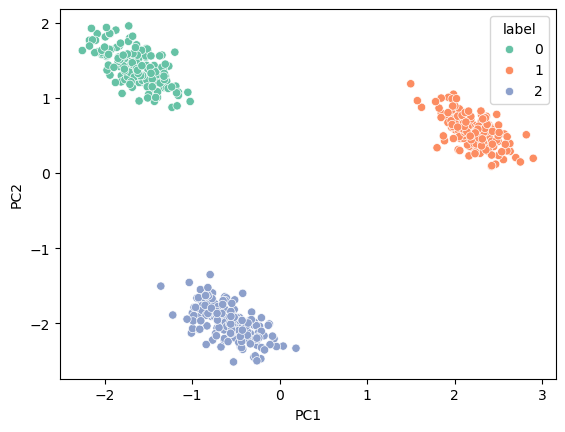

In [70]:
sns.scatterplot(data=df_pca, x = 'PC1', y='PC2', hue='label', palette='Set2')